# TD3 Continuous Analysis — MountainCarContinuous-v0

**Assignment RLI 22.00 — Tinder for RL**  
**Part 03 | Scenario 3: Continuous MountainCar, Cost ∝ Action Intensity**

This notebook analyzes the trained TD3 agent on `MountainCarContinuous-v0`.  
The environment's reward already penalises action intensity: `r_step = -0.1 * a²`.  
The agent must reach position ≥ 0.45 while minimising the force it applies.

Sections:
1. Learning curve (reward and cost over training)
2. Action intensity analysis (cost distribution, action magnitude histogram)
3. Policy visualisation (continuous actor output over the state space)
4. Q-value surface (V(s) = Q(s, π(s)))
5. Phase portrait (trajectories of the trained agent)
6. Physical interpretation
7. Summary statistics

## 0. Imports and Setup

In [1]:
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d import Axes3D
import gymnasium as gym
import torch
import os

# Repo root is the directory that contains agents/
# Works whether Jupyter was launched from root or from analysis/
_cwd = os.getcwd()
CURRENT_DIR = _cwd if os.path.isdir(os.path.join(_cwd, "agents")) else os.path.dirname(_cwd)
print("Repo root:", CURRENT_DIR)

# Load TD3Agent dynamically (same pattern as the other notebooks)
AGENT_PATH = os.path.join(CURRENT_DIR, "agents", "agent_td3.py")
_spec = importlib.util.spec_from_file_location("agent_td3", AGENT_PATH)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
TD3Agent = _mod.TD3Agent
Actor = _mod.Actor
Critic = _mod.Critic

print("Agent loaded from:", AGENT_PATH)

GRAPHS_DIR = os.path.join(CURRENT_DIR, "results", "td3_graphs")
os.makedirs(GRAPHS_DIR, exist_ok=True)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

Repo root: /Users/dianacordovez/TinderForRL
Agent loaded from: /Users/dianacordovez/TinderForRL/agents/agent_td3.py


## 1. Load Trained Artifacts

In [2]:
MODELS_DIR  = os.path.join(CURRENT_DIR, "results", "models")
METRICS_DIR = os.path.join(CURRENT_DIR, "results", "metrics")

rewards     = np.load(os.path.join(METRICS_DIR, "td3_rewards.npy"))
costs       = np.load(os.path.join(METRICS_DIR, "td3_costs.npy"))
steps       = np.load(os.path.join(METRICS_DIR, "td3_steps.npy"))

# Reconstruct agent to load weights
env = gym.make("MountainCarContinuous-v0")
state_dim  = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])

agent = TD3Agent(state_dim=state_dim, action_dim=action_dim, max_action=max_action)
agent.load(os.path.join(MODELS_DIR, "td3_continuous.pt"))
agent.actor.eval()
agent.critic.eval()

print(f"Loaded model. Total episodes: {len(rewards)}")
print(f"Max reward: {np.max(rewards):.2f} | Min: {np.min(rewards):.2f}")
print(f"Successes (reward > 90): {np.sum(rewards > 90)}")

Loaded model. Total episodes: 500
Max reward: 95.24 | Min: -33.93
Successes (reward > 90): 443


## 2. Learning Curve

Two signals:
- **Reward**: raw environment reward (-0.1·a² per step, +100 at goal). The honest performance metric.
- **Cost**: cumulative action intensity per episode (sum of 0.1·a²). Lower is better — the agent is lazy by design.

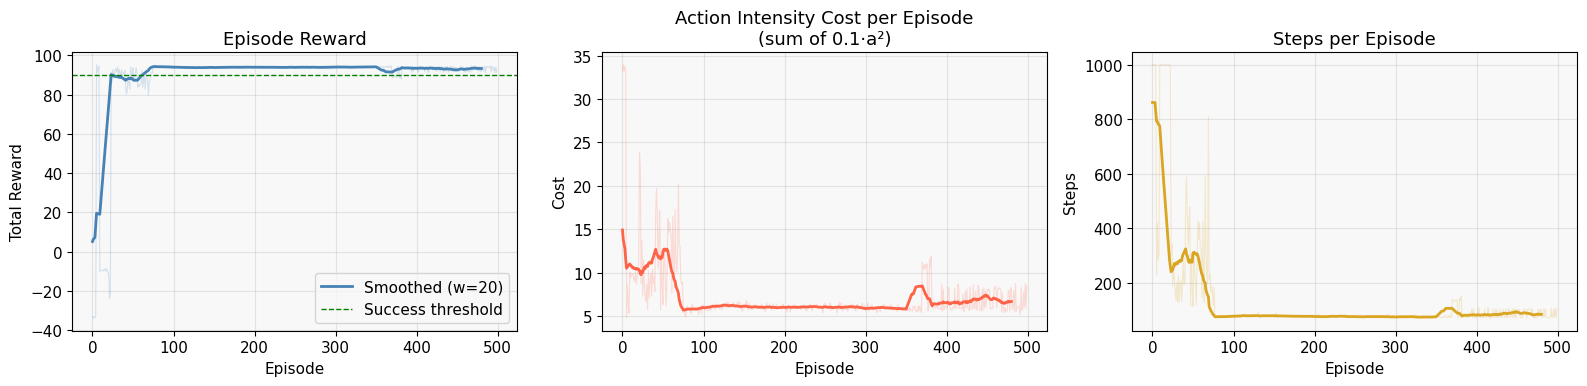

In [3]:
def smooth(x, w=20):
    return np.convolve(x, np.ones(w) / w, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Reward
ax = axes[0]
ax.plot(rewards, alpha=0.2, color="steelblue", linewidth=0.8)
ax.plot(np.arange(len(smooth(rewards))), smooth(rewards), color="steelblue", linewidth=2, label="Smoothed (w=20)")
ax.axhline(90, color="green", linestyle="--", linewidth=1, label="Success threshold")
ax.set_title("Episode Reward")
ax.set_xlabel("Episode")
ax.set_ylabel("Total Reward")
ax.legend()

# Cost
ax = axes[1]
ax.plot(costs, alpha=0.2, color="tomato", linewidth=0.8)
ax.plot(np.arange(len(smooth(costs))), smooth(costs), color="tomato", linewidth=2)
ax.set_title("Action Intensity Cost per Episode\n(sum of 0.1·a²)")
ax.set_xlabel("Episode")
ax.set_ylabel("Cost")

# Steps
ax = axes[2]
ax.plot(steps, alpha=0.2, color="goldenrod", linewidth=0.8)
ax.plot(np.arange(len(smooth(steps))), smooth(steps), color="goldenrod", linewidth=2)
ax.set_title("Steps per Episode")
ax.set_xlabel("Episode")
ax.set_ylabel("Steps")

plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "learning_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

## 3. Action Intensity Analysis

Run the trained greedy policy for several episodes and record the raw action values.  
This reveals **how hard** the agent pushes and **when** in the episode it applies force.

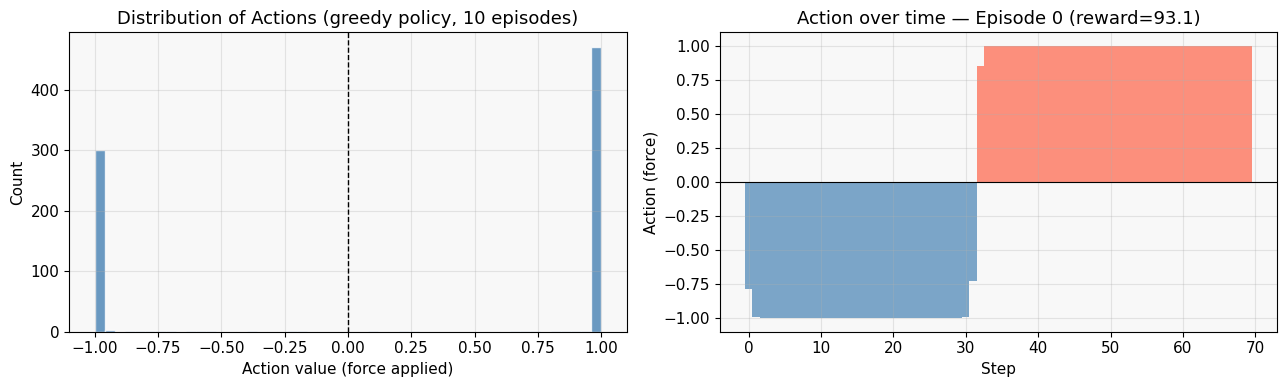

Mean |action|: 0.9879
Fraction of near-zero actions (|a| < 0.05): 0.00%


In [4]:
def run_episode_record(env, agent, seed=None):
    """Run one greedy episode, return (positions, velocities, actions, reward)."""
    obs, _ = env.reset(seed=seed)
    positions, velocities, actions_taken = [], [], []
    total_reward = 0.0
    for _ in range(1000):
        action = agent.select_action(obs, noise_std=0.0)
        positions.append(obs[0])
        velocities.append(obs[1])
        actions_taken.append(float(action[0]))
        obs, r, terminated, truncated, _ = env.step(action)
        total_reward += r
        if terminated or truncated:
            break
    return np.array(positions), np.array(velocities), np.array(actions_taken), total_reward

eval_env = gym.make("MountainCarContinuous-v0")
trajectories = [run_episode_record(eval_env, agent, seed=i) for i in range(10)]

all_actions = np.concatenate([t[2] for t in trajectories])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram of action magnitudes
ax = axes[0]
ax.hist(all_actions, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Distribution of Actions (greedy policy, 10 episodes)")
ax.set_xlabel("Action value (force applied)")
ax.set_ylabel("Count")

# Action magnitude over time for one episode
ax = axes[1]
pos, vel, acts, rew = trajectories[0]
t = np.arange(len(acts))
ax.bar(t, acts, color=["tomato" if a > 0 else "steelblue" for a in acts], alpha=0.7, width=1.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"Action over time — Episode 0 (reward={rew:.1f})")
ax.set_xlabel("Step")
ax.set_ylabel("Action (force)")

plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "action_intensity.png"), dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean |action|: {np.mean(np.abs(all_actions)):.4f}")
print(f"Fraction of near-zero actions (|a| < 0.05): {np.mean(np.abs(all_actions) < 0.05):.2%}")

## 4. Policy Visualisation

Unlike the Q-table, the TD3 actor outputs a **continuous** force value for every state.  
We sweep a grid over (position, velocity) and query the actor network directly.

- **Warm colours** (red) = push right (positive force)
- **Cool colours** (blue) = push left (negative force)
- **White / near-zero** = do nothing (cost-efficient)

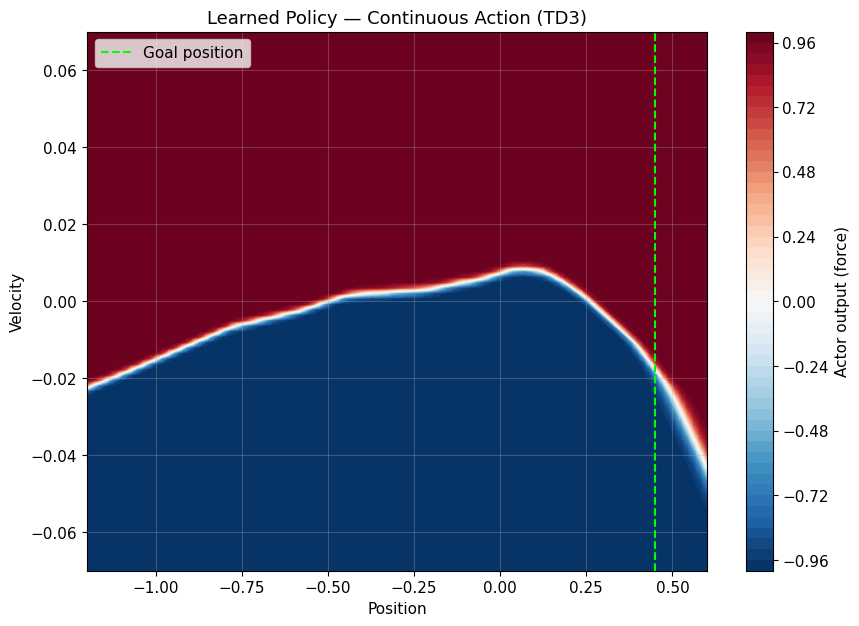

In [5]:
pos_range = np.linspace(env.observation_space.low[0], env.observation_space.high[0], 100)
vel_range = np.linspace(env.observation_space.low[1], env.observation_space.high[1], 100)

POS, VEL = np.meshgrid(pos_range, vel_range)  # each (100, 100)
states_grid = np.stack([POS.ravel(), VEL.ravel()], axis=1).astype(np.float32)

with torch.no_grad():
    actions_grid = agent.actor(torch.FloatTensor(states_grid)).cpu().numpy().reshape(100, 100)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.contourf(POS, VEL, actions_grid, levels=50, cmap="RdBu_r", vmin=-1, vmax=1)
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Actor output (force)")
ax.set_title("Learned Policy — Continuous Action (TD3)")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.axvline(0.45, color="lime", linewidth=1.5, linestyle="--", label="Goal position")
ax.legend()

plt.savefig(os.path.join(GRAPHS_DIR, "policy.png"), dpi=150, bbox_inches='tight')
plt.show()

## 5. Q-Value Surface

V(s) = Q(s, π(s)) — the state value under the learned policy.  
We use the minimum of the two critic networks (conservative estimate, as in TD3).

States near the goal should have high value; the valley floor should be low.

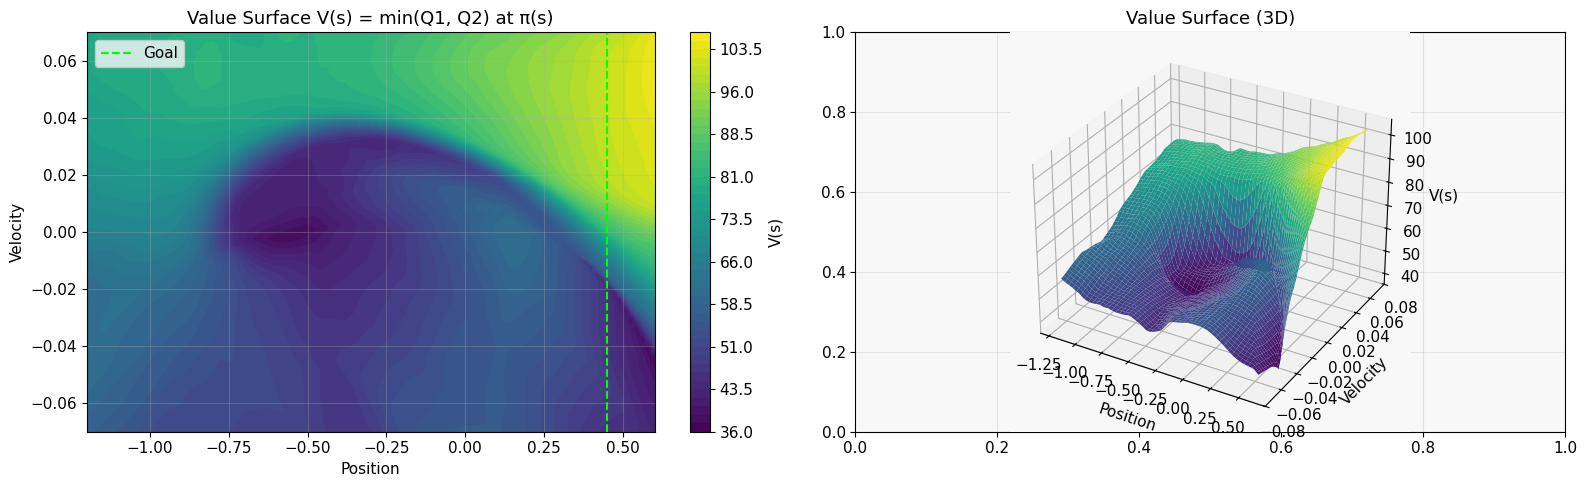

In [6]:
with torch.no_grad():
    states_t  = torch.FloatTensor(states_grid)
    actions_t = agent.actor(states_t)
    q1, q2 = agent.critic(states_t, actions_t)
    V = torch.min(q1, q2).cpu().numpy().reshape(100, 100)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 2D heatmap
ax = axes[0]
im = ax.contourf(POS, VEL, V, levels=50, cmap="viridis")
plt.colorbar(im, ax=ax, label="V(s)")
ax.set_title("Value Surface V(s) = min(Q1, Q2) at π(s)")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.axvline(0.45, color="lime", linewidth=1.5, linestyle="--", label="Goal")
ax.legend()

# 3D surface
ax3d = fig.add_subplot(122, projection='3d')
ax3d.plot_surface(POS, VEL, V, cmap="viridis", linewidth=0, antialiased=True)
ax3d.set_title("Value Surface (3D)")
ax3d.set_xlabel("Position")
ax3d.set_ylabel("Velocity")
ax3d.set_zlabel("V(s)")

plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "value_surface.png"), dpi=150, bbox_inches='tight')
plt.show()

## 6. Phase Portrait — Trajectories in State Space

Plot the agent's trajectory in (position, velocity) space.  
A successful agent builds momentum by rocking back and forth before the final push to the goal.  
The **amplitude** of the trajectory should grow over the episode.

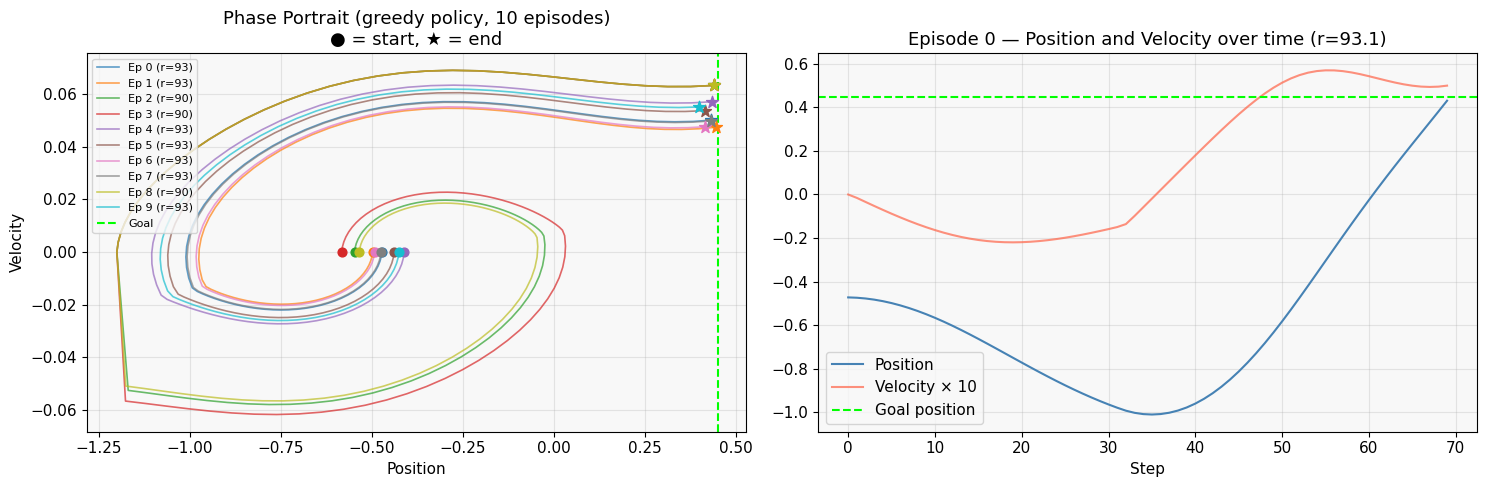

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
cmap_traj = plt.cm.tab10

# Phase portrait
ax = axes[0]
for i, (pos, vel, acts, rew) in enumerate(trajectories):
    color = cmap_traj(i / 10)
    ax.plot(pos, vel, color=color, alpha=0.7, linewidth=1.2, label=f"Ep {i} (r={rew:.0f})")
    ax.scatter(pos[0], vel[0], color=color, marker='o', s=40, zorder=5)
    ax.scatter(pos[-1], vel[-1], color=color, marker='*', s=80, zorder=5)

ax.axvline(0.45, color="lime", linewidth=1.5, linestyle="--", label="Goal")
ax.set_title("Phase Portrait (greedy policy, 10 episodes)\n● = start, ★ = end")
ax.set_xlabel("Position")
ax.set_ylabel("Velocity")
ax.legend(fontsize=8, loc='upper left')

# Position over time for the first episode
ax = axes[1]
pos, vel, acts, rew = trajectories[0]
t = np.arange(len(pos))
ax.plot(t, pos, color="steelblue", label="Position")
ax.plot(t, vel * 10, color="tomato", alpha=0.7, label="Velocity × 10")
ax.axhline(0.45, color="lime", linewidth=1.5, linestyle="--", label="Goal position")
ax.set_title(f"Episode 0 — Position and Velocity over time (r={rew:.1f})")
ax.set_xlabel("Step")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "phase_portrait.png"), dpi=150, bbox_inches='tight')
plt.show()

## 7. Physical Interpretation

The Mountain Car is a **forced harmonic oscillator**. The car's natural resonant frequency is determined by the slope of the hill. The optimal policy exploits this: apply force **in the direction of motion** to build amplitude, and only apply large forces near the extremes where momentum transfer is most efficient.

With a cost on action intensity (−0.1·a²), the agent learns to:
1. Use **small forces** rather than saturating at ±1
2. Apply force **only when it matters** — near the extremes of the rocking motion
3. Coast during the middle of the swing (near the valley)

Compare this to the discrete Scenario 2 agent (cost on non-null actions): that agent was incentivised to take the **null action** as often as possible. This agent is incentivised to apply **gentle force** rather than no force — a subtly different behaviour.

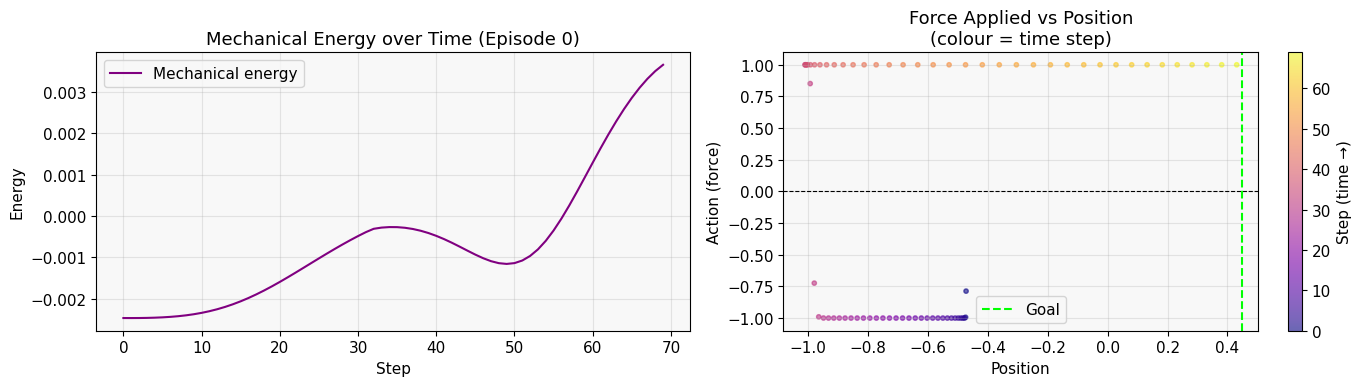

In [8]:
def compute_energy(pos, vel, gravity=0.0025):
    ke = 0.5 * vel ** 2
    pe = gravity * np.sin(3 * pos)
    return ke + pe

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pos, vel, acts, rew = trajectories[0]
energy = compute_energy(pos, vel)
t = np.arange(len(pos))

# Energy over time
ax = axes[0]
ax.plot(t, energy, color="purple", linewidth=1.5, label="Mechanical energy")
ax.set_title("Mechanical Energy over Time (Episode 0)")
ax.set_xlabel("Step")
ax.set_ylabel("Energy")
ax.legend()

# Action vs position (where does the agent apply force?)
ax = axes[1]
sc = ax.scatter(pos, acts, c=t, cmap="plasma", s=10, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Step (time →)")
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.axvline(0.45, color="lime", linewidth=1.5, linestyle="--", label="Goal")
ax.set_title("Force Applied vs Position\n(colour = time step)")
ax.set_xlabel("Position")
ax.set_ylabel("Action (force)")
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(GRAPHS_DIR, "physical_interpretation.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary Statistics

In [9]:
successes = np.sum(rewards > 90)
last_100  = rewards[-100:]

print("=" * 55)
print("  TD3 SUMMARY — MountainCarContinuous-v0")
print("=" * 55)
print(f"  Algorithm        : TD3 (Twin Delayed DDPG)")
print(f"  State space      : continuous R² (position, velocity)")
print(f"  Action space     : continuous [-1, 1] (force)")
print(f"  Cost signal      : -0.1 · a² per step (built-in)")
print(f"  Training episodes: {len(rewards)}")
print(f"  Successes (r>90) : {successes} / {len(rewards)} ({100*successes/len(rewards):.1f}%)")
print(f"  Avg reward (all) : {np.mean(rewards):.2f}")
print(f"  Avg reward (last 100): {np.mean(last_100):.2f}")
print(f"  Max reward       : {np.max(rewards):.2f}")
print(f"  Avg cost/episode : {np.mean(costs):.4f}")
print(f"  Avg steps/episode: {np.mean(steps):.1f}")
print("=" * 55)

  TD3 SUMMARY — MountainCarContinuous-v0
  Algorithm        : TD3 (Twin Delayed DDPG)
  State space      : continuous R² (position, velocity)
  Action space     : continuous [-1, 1] (force)
  Cost signal      : -0.1 · a² per step (built-in)
  Training episodes: 500
  Successes (r>90) : 443 / 500 (88.6%)
  Avg reward (all) : 88.99
  Avg reward (last 100): 93.26
  Max reward       : 95.24
  Avg cost/episode : 7.2129
  Avg steps/episode: 136.6
